In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import torch
from prism.config import PROCESSED_DATA_DIR, MODELS_DIR
from prism.PRiSM_functions import normalise
from prism.load_models import load_mlp
from prism.pr_save_test import save_partial_responses, test_refactored_partial_responses, load_partial_responses
from prism.partial_responses import partial_responses, PartialResponseCalculator

2024-08-05 09:45:23.200 | INFO     | prism.config:<module>:11 - PROJ_ROOT path is: C:\Users\Henry Pigot\Documents\MEGAsync\2024 post doc\explainable survival prediction model\prism_github


In [2]:
%reload_ext autoreload

In [3]:
seed = 257
np.random.seed(seed)
torch.manual_seed(seed)

In [4]:
import matplotlib.pyplot as plt

def plot_histograms(pr_train_benchmark, x_train, num_subplot_cols=3):
    # Univariate responses only
    m = x_train.shape[1]

    # Calculate number of rows needed for the subplots
    num_subplot_rows = (m + num_subplot_cols - 1) // num_subplot_cols

    # Create a figure with subplots arranged in 3 columns
    fig, axes = plt.subplots(num_subplot_rows, num_subplot_cols, figsize=(12, 4 * num_subplot_rows))
    fig.suptitle(f'Histograms of Benchmark Training Partial Responses')

    # Plot histogram for each column
    for i in range(m):
        row = i // num_subplot_cols
        col = i % num_subplot_cols
        ax = axes[row, col] if num_subplot_rows > 1 else axes[col]
        ax.hist(pr_train_benchmark[:, i], bins=15, edgecolor='black')
        ax.set_title(x_train.columns[i])
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')

    # Remove any unused subplots
    for i in range(m, num_subplot_rows * num_subplot_cols):
        row = i // num_subplot_cols
        col = i % num_subplot_cols
        fig.delaxes(axes[row, col] if num_subplot_rows > 1 else axes[col])

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

## Load and preprocess data

In [5]:
data_train = pd.read_csv(PROCESSED_DATA_DIR.joinpath('imputed_dataset1_train.csv'))
data_test = pd.read_csv(PROCESSED_DATA_DIR.joinpath('imputed_dataset1_test.csv'))
data_val = pd.read_csv(PROCESSED_DATA_DIR.joinpath('imputed_dataset1_val.csv'))

data_train_test = pd.concat([data_train,data_test]) # used for axis annotation in some plotting functions

# drop id column
data_train.drop('trr_id_code',axis=1,inplace=True)
data_test.drop('trr_id_code',axis=1,inplace=True)
data_val.drop('trr_id_code',axis=1,inplace=True)

target_col = 'oneyearmort'

x_train0 = data_train.drop(target_col,axis=1)
y_train = data_train[target_col]

x_test0 = data_test.drop(target_col,axis=1)
y_test = data_test[target_col]

x_val0 = data_val.drop(target_col,axis=1)
y_val = data_val[target_col]

[x_train,x_test] = normalise(x_train0,x_test0)
x_val = normalise(x_val0)

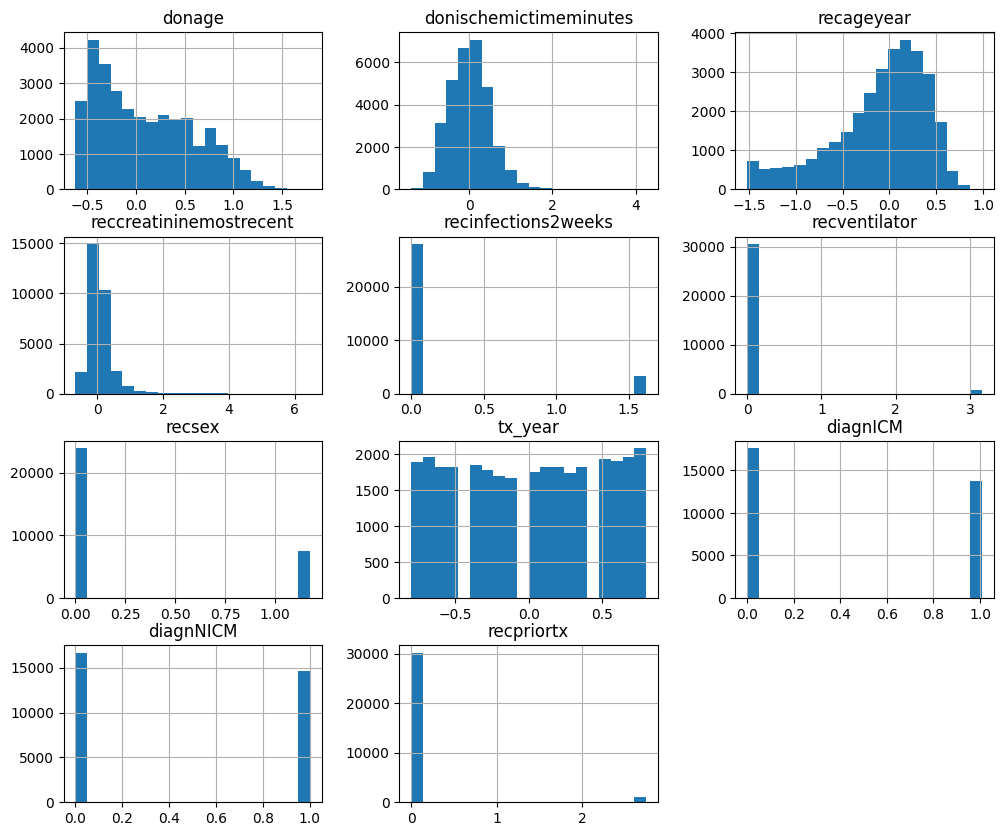

In [6]:
x_train.hist(bins=20,figsize=(12,10));

## Load MLP

In [7]:
filename_mlp = 'mlp_model_20240705_135534'
try:
    mlp, mlp_params, mlp_metrics = load_mlp(filename_mlp, MODELS_DIR)
    print("Model loaded successfully")
    print("Derived Model Structure:")
    print(f"Input dimension: {mlp_params['input_dim']}")
    print(f"Hidden units: {mlp_params['hidden_units']}")
    print(f"Output dimension: {mlp_params['output_dim']}")
    print("\nModel Parameters:")
    print(mlp_params)
    print("\nModel Metrics:")
    print(mlp_metrics)
except Exception as e:
    print(f"Error loading model: {e}")
    raise

# Extract method and device from mlp_params, with defaults
method = mlp_params.get('method', 'dirac')
device = mlp_params.get('device', 'cpu')

Model loaded successfully
Derived Model Structure:
Input dimension: 11
Hidden units: 10
Output dimension: 1

Model Parameters:
{'n_hidden': 10, 'weight_decay': 1e-05, 'lr': 0.001, 'patience': 50, 'tolerance': 0.0001, 'batch_size': 1024, 'device': 'cpu', 'seed': 257, 'input_dim': 11, 'hidden_units': 10, 'output_dim': 1}

Model Metrics:
{'prevalence': 0.123, 'sensitivity': 0.241, 'specificity': 0.864, 'accuracy': 0.797, 'ppv': 0.175, 'auc score': 0.601, 'auc lower ci': '0.577', 'auc upper ci': '0.626'}


## Load benchmark partial responses

In [8]:
pr_load = load_partial_responses()
pr_train_benchmark = pr_load['partial_responses_train']
pr_test_benchmark = pr_load['partial_responses_test']

Data successfully loaded from C:\Users\Henry Pigot\Documents\MEGAsync\2024 post doc\explainable survival prediction model\prism_github\models\partial_responses_data.pkl
Loaded data contains the following keys: x_train, x_test, model, partial_responses_train, partial_responses_test, method, device
x_train shape: (31315, 11)
x_test shape: (6120, 11)
partial_responses_train shape: (31315, 66)
partial_responses_test shape: (6120, 66)


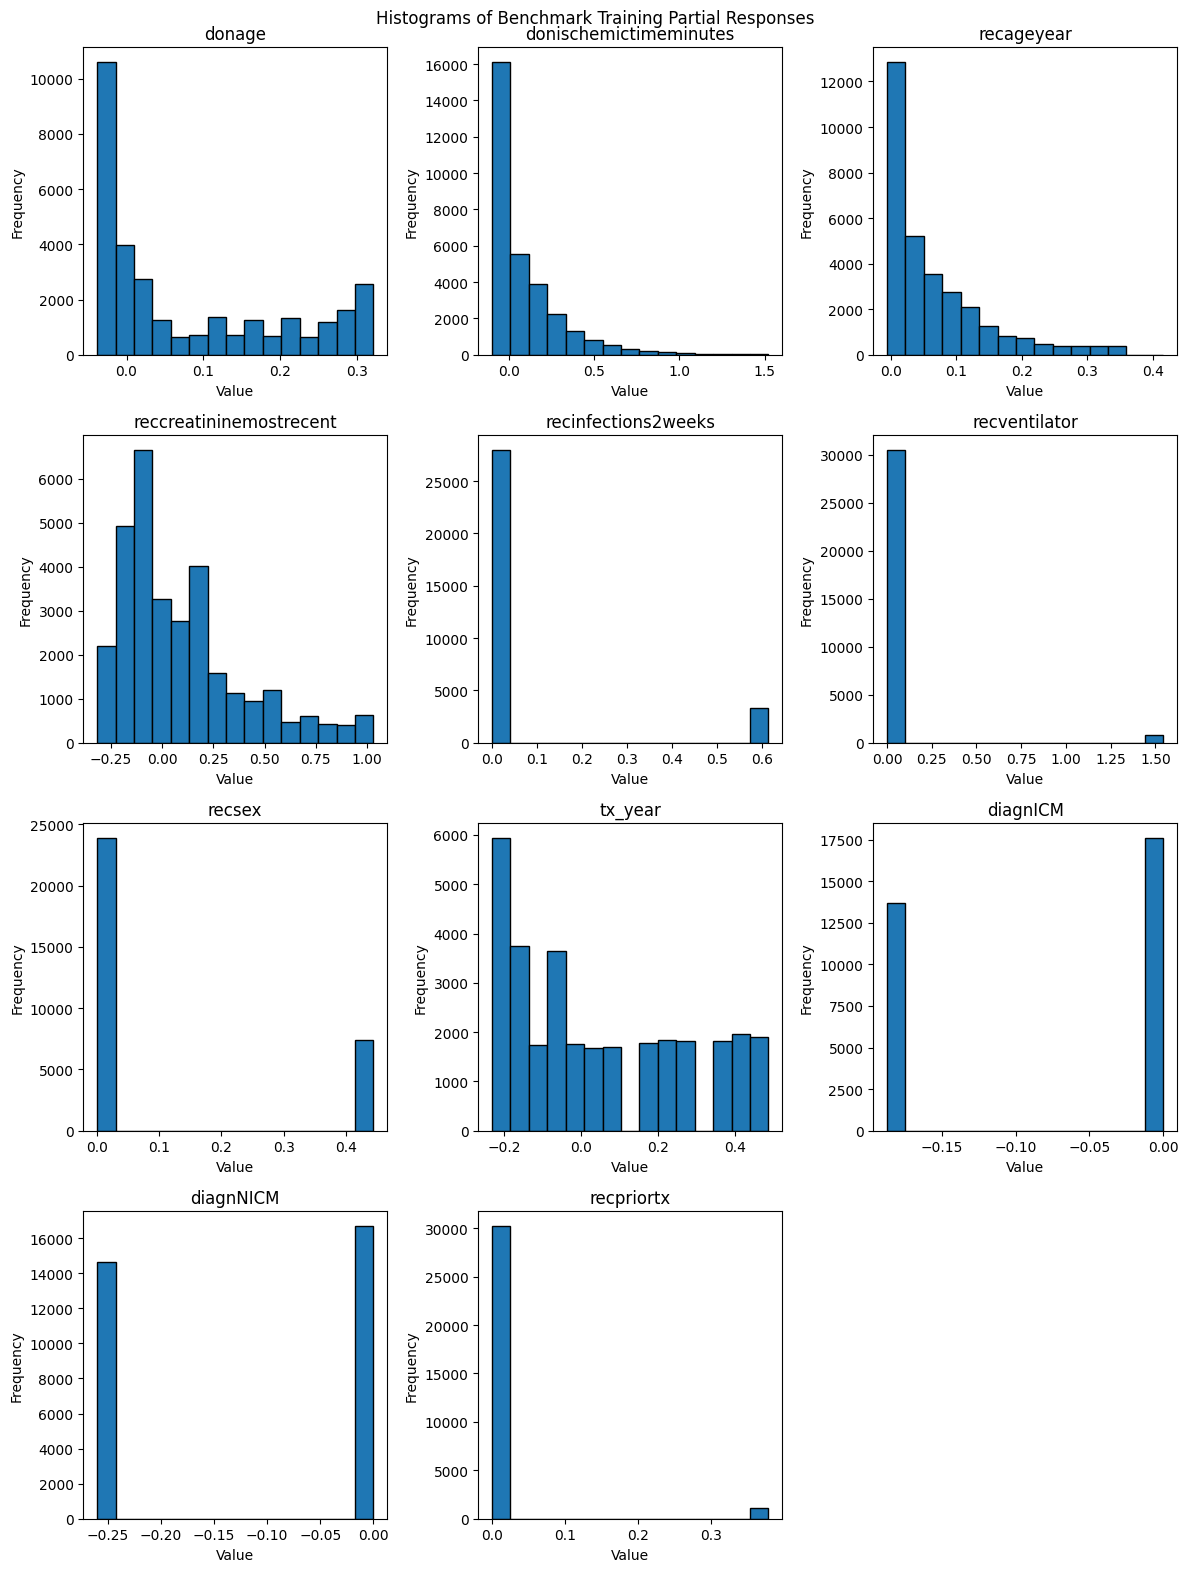

In [9]:
plot_histograms(pr_train_benchmark,x_train)

## Test new implementation `partial_responses`

In [10]:
x_train_tensor = torch.tensor(x_train.values, dtype=torch.float32)
x_test_tensor = torch.tensor(x_test.values, dtype=torch.float32)

### Test Dirac

In [11]:
pr = PartialResponseCalculator(mlp, method, device, input_dim=x_train_tensor.shape[1])

In [12]:
univariate_train, bivariate_train, bivariate_inputs = pr.calculate(x_train_tensor)

In [13]:
pr_train, pr_test, bivariate_inputs = partial_responses(x_train_tensor,x_test_tensor,mlp,method='dirac',device=device)

In [14]:
print(f"First few univariate responses (train): {pr_train[:5, :5]}")
print(f"First few bivariate responses (train): {pr_train[:5, 11:16]}")
print(f"First few univariate responses (test): {pr_test[:5, :5]}")
print(f"First few bivariate responses (test): {pr_test[:5, 11:16]}")

First few univariate responses (train): tensor([[ 0.0716, -0.0867, -0.0057,  0.2100,  0.0000],
        [-0.0269,  0.1127, -0.0032, -0.1168,  0.0000],
        [ 0.2512, -0.0407,  0.0694,  0.0664,  0.0000],
        [ 0.2083,  0.6771,  0.0565,  0.4328,  0.0000],
        [-0.0382, -0.0836,  0.0169, -0.2702,  0.0000]])
First few bivariate responses (train): tensor([[ 0.0065, -0.0075, -0.0054,  0.0000,  0.0000],
        [ 0.0166,  0.0041, -0.0159,  0.0000,  0.0000],
        [-0.0001,  0.0402, -0.0058,  0.0000,  0.0000],
        [-0.0387,  0.0310, -0.0015,  0.0000,  0.0000],
        [-0.0411, -0.0092, -0.0393,  0.0000,  0.0000]])
First few univariate responses (test): tensor([[-0.0102,  0.1832,  0.0044,  0.0664,  0.0000],
        [-0.0382,  0.0829,  0.2849,  0.1513,  0.0000],
        [-0.0326,  0.2240,  0.0342,  0.0000,  0.0000],
        [-0.0269, -0.0407,  0.1513, -0.0435,  0.0000],
        [ 0.3009,  0.1306,  0.1152,  0.5716,  0.0000]])
First few bivariate responses (test): tensor([[ 0.0281

In [15]:
print(f"First few univariate responses (train): {pr_train_benchmark[:5, :5]}")
print(f"First few bivariate responses (train): {pr_train_benchmark[:5, 11:16]}")
print(f"First few univariate responses (test): {pr_test_benchmark[:5, :5]}")
print(f"First few bivariate responses (test): {pr_test_benchmark[:5, 11:16]}")

First few univariate responses (train): [[ 0.07161093 -0.08673906 -0.00569773  0.20996237  0.        ]
 [-0.02694654  0.11274576 -0.00319147 -0.11675644  0.        ]
 [ 0.25121975 -0.04073429  0.06940937  0.06640053  0.        ]
 [ 0.20826769  0.67714942  0.05648136  0.43277049  0.        ]
 [-0.03824949 -0.08359814  0.01686096 -0.27024698  0.        ]]
First few bivariate responses (train): [[ 0.00654554 -0.00751519 -0.00542164  0.          0.        ]
 [ 0.01660681  0.00406265 -0.01590681  0.          0.        ]
 [-0.00010848  0.04021502 -0.00579095  0.          0.        ]
 [-0.03867877  0.03100348 -0.00154138  0.          0.        ]
 [-0.04112434 -0.00924683 -0.03928757  0.          0.        ]]
First few univariate responses (test): [[-0.01015663  0.1832056   0.0043993   0.06640053  0.        ]
 [-0.03822756  0.08289409  0.28486729  0.15125036  0.        ]
 [-0.03259659  0.22404289  0.03423142  0.          0.        ]
 [-0.02694654 -0.04073429  0.15129423 -0.04352379  0.        

In [16]:
## test dirac
test_refactored_partial_responses(partial_responses,tensor_input=True)

Refactored function produces different results from the original implementation. atol = 1e-07, rtol = 1e-05
Differences found in partial_responses_train
Max absolute difference: 4.76837158203125e-07
Max relative difference: 4.1355603601576815e-05
Differences found in partial_responses_test
Max absolute difference: 4.76837158203125e-07
Max relative difference: 3.675994871251956e-05


False

### Test Lebesgue

In [21]:
# Load results from old method
pr_load_leb= load_partial_responses("partial_responses_data_leb500.pkl")
pr_train_benchmark_leb = pr_load_leb['partial_responses_train']
pr_test_benchmark_leb = pr_load_leb['partial_responses_test']

Data successfully loaded from partial_responses_data_leb500.pkl
Loaded data contains the following keys: x_train, x_test, model, partial_responses_train, partial_responses_test, method, device
x_train shape: (500, 11)
x_test shape: (500, 11)
partial_responses_train shape: (500, 66)
partial_responses_test shape: (500, 66)


In [22]:
print(f"First few univariate responses (train): {pr_train_benchmark_leb[:5, :5]}")
print(f"First few bivariate responses (train): {pr_train_benchmark_leb[:5, 11:16]}")
print(f"First few univariate responses (test): {pr_test_benchmark_leb[:5, :5]}")
print(f"First few bivariate responses (test): {pr_test_benchmark_leb[:5, 11:16]}")

First few univariate responses (train): [[ 0.02279246 -0.13538277 -0.08238709  0.05137408 -0.04876649]
 [-0.18926609  0.06411755 -0.04966962 -0.16132271 -0.04876649]
 [ 0.24780893 -0.07403123  0.07245362 -0.04652226 -0.04876649]
 [ 0.1899035   0.45994484  0.0572989   0.2237339  -0.04876649]
 [-0.1667074  -0.20167506  0.00046611 -0.25231373 -0.04876649]]
First few bivariate responses (train): [[ 0.00975614 -0.0014504  -0.00784853  0.0015941  -0.00162662]
 [ 0.00449143 -0.00350396 -0.01813054 -0.00167009 -0.00617562]
 [ 0.00969791  0.01454909 -0.00556087  0.0005069   0.00979852]
 [-0.05770344  0.01386476 -0.0322869   0.00121743  0.00653278]
 [-0.0161572  -0.00503564 -0.03246517 -0.00096593 -0.00687471]]
First few univariate responses (test): [[-0.53211224 -0.39187014 -0.45838583 -0.41380584 -0.44975626]
 [-0.54525983 -0.43861377 -0.47356451 -0.33227766 -0.44975626]
 [-0.54459131 -0.37141097 -0.40668476 -0.47929466 -0.44975626]
 [-0.54169858 -0.48624599 -0.27472937 -0.52340114 -0.44975626

In [18]:
# View new lebesgue results
pr_train_leb, pr_test_leb, bivariate_inputs_leb = partial_responses(x_train_tensor[:500,:],x_test_tensor[:500,:],mlp,method='lebesgue',device=device)

In [19]:
print(f"First few univariate responses (train): {pr_train_leb[:5, :5]}")
print(f"First few bivariate responses (train): {pr_train_leb[:5, 11:16]}")
print(f"First few univariate responses (test): {pr_test_leb[:5, :5]}")
print(f"First few bivariate responses (test): {pr_test_leb[:5, 11:16]}")

First few univariate responses (train): tensor([[ 0.0228, -0.1354, -0.0824,  0.0514, -0.0488],
        [-0.1893,  0.0641, -0.0497, -0.1613, -0.0488],
        [ 0.2478, -0.0740,  0.0725, -0.0465, -0.0488],
        [ 0.1899,  0.4599,  0.0573,  0.2237, -0.0488],
        [-0.1667, -0.2017,  0.0005, -0.2523, -0.0488]])
First few bivariate responses (train): tensor([[ 0.0098, -0.0015, -0.0078,  0.0016, -0.0016],
        [ 0.0045, -0.0035, -0.0181, -0.0017, -0.0062],
        [ 0.0097,  0.0145, -0.0056,  0.0005,  0.0098],
        [-0.0577,  0.0139, -0.0323,  0.0012,  0.0065],
        [-0.0162, -0.0050, -0.0325, -0.0010, -0.0069]])
First few univariate responses (test): tensor([[-0.5321, -0.3919, -0.4584, -0.4138, -0.4498],
        [-0.5453, -0.4386, -0.4736, -0.3323, -0.4498],
        [-0.5446, -0.3714, -0.4067, -0.4793, -0.4498],
        [-0.5417, -0.4862, -0.2747, -0.5234, -0.4498],
        [-0.1191, -0.4170, -0.3111,  0.0644, -0.4498]])
First few bivariate responses (test): tensor([[0.4250,

In [20]:
# Test lebesgue
test_refactored_partial_responses(partial_responses,filename="partial_responses_data_leb500.pkl", tensor_input=True)

Refactored function produces different results from the original implementation. atol = 1e-07, rtol = 1e-05
Differences found in partial_responses_train
Max absolute difference: 9.936047717928886e-07
Max relative difference: 8.713168888429998e-05
Differences found in partial_responses_test
Max absolute difference: 1.0132789611816406e-06
Max relative difference: 3.3892147053959016e-05


False